# Portfolio loss and importance sampling.

Let $V(S)$ be the value of a portfolio value consisting of
financial instruments based on $m$ market prices $S \in \mathbb{R}^m$. The goal of this project is
to use Monte Carlo to estimate the portfolio loss $L$ over short time periods $\Delta T$. Here, it
is common to use the delta-gamma representation, where the loss is written as
$$
L:=\delta^{\top} \Delta S+(\Delta S)^{\top} \Gamma \Delta S,
$$
where $\delta \in \mathbb{R}^m, \Gamma \in \mathbb{R}^{m \times m}$ and $\Delta S \sim N\left(0,
\Sigma_S\right)$ for some covariance matrix $\Sigma_S$. Sometimes, it is helpful to consider the
linear approximation
$$
Q:=\delta^{\top} \Delta S .
$$
First, assume that $m=1, \delta=2, \Gamma=\Sigma_S=1$, and $x=10$. 
Please always justify your answer.

In [187]:
# setup (only needed once, this cell is hidden in export)
import numpy as np
import matplotlib.pyplot as plt
from random import random, seed
from random import uniform
from sklearn.linear_model import LinearRegression
from scipy.stats import norm, multivariate_normal, ncx2
seed(2)
np.random.seed(2)

## Questions
 

 
> #### Exercise a)
> Write a program to estimate the exceedance probabilities $\mathbb{P}(L>x)$ by crude Monte Carlo simulation.

Using the given parameters we can write:
$$
\mathbb{P}(L > x) = \mathbb{P}(2Z + Z^2 >x) \quad Z \sim N(0,1)
$$
Completing the square we get $2Z + Z^2 =(Z+1)^2-1= Y^2 - 1$ where $Y \sim X^2_{nc}(\nu = 1, \lambda = 1)$ where $X^2_{nc}(\nu, \lambda)$ denotes a non-central chi-square distribution with $\nu$ degrees of freedom and non-centrality parameter $\lambda$. In particular the analytical probability is can be calulated by:
$$
\mathbb{P}(L > x) = 1 - \mathbb{P}(Y^2 -1 \le x ) = 1 - \mathbb{P}(Y^2 \le x +1)
$$
In code:

In [188]:
x = 10
analytical_prop = 1-ncx2.cdf(x+1, df=1, nc=1)
print(f"Analytical probability P(L > {x}): {analytical_prop:.6f}")

Analytical probability P(L > 10): 0.010270


In [189]:
# assumptions
m = 1
delta = 2
gamma = 1
sigma = np.array([[1]])  # covariance matrix


# number of simulations
N = 10**4


def loss(m, delta, delta_S, gamma):
    """ Compute the loss L given delta, gamma, sigma and delta_S, note that all parameters shold be of dimension m."""
    if m == 1:
        L = delta*delta_S + gamma*delta_S**2
    else:
        L = delta.T@delta_S + delta_S.T@gamma@delta_S
    return L


def crude_monte_carlo(N, m, delta, gamma, sigma, x, loss_function):
    """ Crude Monte Carlo simulation of the probability P(L > x), note that all parameters shold be of dimension m."""
    delta_S = np.random.multivariate_normal(np.zeros(m), sigma, N)
    L = loss_function(m, delta, delta_S, gamma)
    return np.mean(L > x), L


P_crude, L = crude_monte_carlo(N, m, delta, gamma, sigma, x, loss)
print(f"Crude Monte Carlo estimate of P(L > {x}): {P_crude:.6f}")

Crude Monte Carlo estimate of P(L > 10): 0.010400


> #### Exercise b)
>  Use control variables method to reduce the variance of the estimator from part (a).  Discuss several possibilities and argue for your final choice.  Would you recommend to use these methods given potential longer compute time?

Optimal beta: 0.0000
Control Variance (estimator 1) Monte Carlo estimate of P(L > 10): 0.010000
Variance reduction: 1.00 times
Optimal beta: 0.0150
Control Variance (estimator 2) Monte Carlo estimate of P(L > 10): 0.011200
Variance reduction: 1.09 times


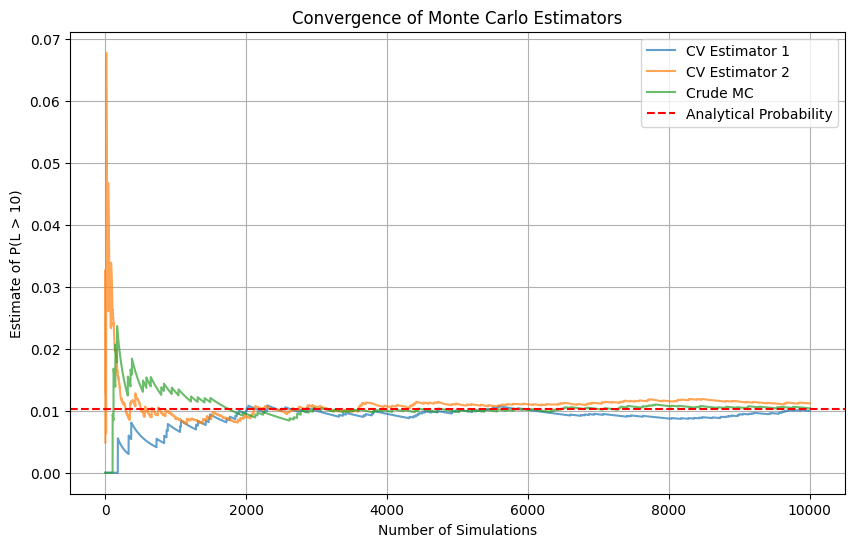

In [190]:
def estimator(m, delta, delta_S, *args):
    """Initially proposed linear estimator of L, note that all parameters shold be of dimension m."""

    if m == 1:
        return delta*delta_S
    else:
        return delta.T@delta_S


P_crude_estimate, Q = crude_monte_carlo(N, m, delta, gamma, sigma, x, estimator)



def cv_estimator_1(Z, x, *args):
    """Simplest control variance estimator using Z as control variate."""
    H = Z > x/2
    return H, np.mean(H)


def cv_estimator_2(Z, x, *args):
    """Simplest control variance estimator using Z as control variate."""
    delta, m = args
    H = estimator(m, delta, Z, gamma)
    #print(f"Mean of control variate: {np.mean(H):.4f}")

    return H, np.mean(H)

def control_variance_monte_carlo(N, m, delta, x, control_variance_estimator):
    """ Control Variance monte carlo of P(L>x), note that all parameters shold be of dimension m."""

    # Create simulation
    Z = np.random.multivariate_normal(np.zeros(m), sigma, N)
    Y = loss(m, delta, Z, gamma) > x
    H, l_H = control_variance_estimator(Z, x, delta, m)

    model = LinearRegression()
    beta = model.fit(H,  Y).coef_
    print(f"Optimal beta: {beta.item():.4f}")

    Y_hat = Y - beta*(H - l_H)
    if m == 1:
        return np.mean(Y_hat), Y, Y_hat
    else:
        pass


P_crude_cv_1, Y_1, Y_hat_1 = control_variance_monte_carlo(
    N, m, delta, x, cv_estimator_1)
print(f"Control Variance (estimator 1) Monte Carlo estimate of P(L > {x}): {P_crude_cv_1:.6f}")
print(f"Variance reduction: {np.var(Y_1)/np.var(Y_hat_1):.2f} times")


P_crude_cv_2, Y_2, Y_hat_2 = control_variance_monte_carlo(
    N, m, delta, x, cv_estimator_2)
print(f"Control Variance (estimator 2) Monte Carlo estimate of P(L > {x}): {P_crude_cv_2:.6f}")
print(f"Variance reduction: {np.var(Y_2)/np.var(Y_hat_2):.2f} times")

# create a plot of the convergence of the probability estimates
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(Y_hat_1)/np.arange(1, N+1), label='CV Estimator 1', alpha=0.7)
plt.plot(np.cumsum(Y_hat_2)/np.arange(1, N+1), label='CV Estimator 2', alpha=0.7)
plt.plot(np.cumsum(L > x)/np.arange(1, N+1), label='Crude MC', alpha=0.7)
plt.axhline(analytical_prop, color='red', linestyle='--', label='Analytical Probability')
plt.xlabel('Number of Simulations')
plt.ylabel(f'Estimate of P(L > {x})')
plt.title('Convergence of Monte Carlo Estimators')
plt.legend()
plt.grid()
plt.show()


> #### Exercise c)
> Design an importance-sampling method to reduce the variance of the estimator from part (a). Again, discuss several options and argue for your final choice. Again, discuss the trade-off between additional compute time and variance reduction.

> #### Exercise d)
>  Create and discuss visualizations for comparing (a), (b) and (c).

> #### Exercise e)
> Show that for the specific choices of $m, \delta, \Gamma$ and $\Sigma_S$, the probability $\mathbb{P}(L>x)$ has a closed-form expression only involving the cdf of the standard normal distribution. Is this still true when choosing another distribution? For the variance-reduction methods in (b), (c), how easy do they generalize when $L$ is replaced by another relevant distribution?

> #### Question 1)
> Now, assume that $m=2, \delta=(2,2)^{\top}, \Gamma=I d_2, \Sigma_S=\left(\begin{array}{cc}1 & 0.5 \\ 0.5 & 1\end{array}\right)$, and $x=15$. Repeat parts (a) and (b) for these new parameters.

> #### Exercise f)
> Now, use the Cholesky decomposition to find a matrix $\widetilde{C}$ such that $\Delta S=\widetilde{C} Z$ where $Z \sim N\left(0, I_2\right)$. Next, find an orthogonal matrix $U$ and a diagonal matrix $\Lambda=\operatorname{diag}\left(\lambda_1, \lambda_2\right)$ such that $\widetilde{C}^{\top} \widetilde{C}=U \Lambda U^{\top}$. Show that the loss $L$ can be expressed as $$ L=b_1 Z_1+b_2 Z_2+\lambda_1 Z_1^2+\lambda_2 Z_2^2 $$ where $b=C^{\top} \delta$ with $C=\widetilde{C} U$.

> #### Exercise g)
> Similarly as in part (c), use $\prod_{i \leq 2} \exp \left(\theta_i Z_i-\psi^*\left(\theta_i\right)\right)$ as an importance-sampling density, where $\psi^*$ is the cumulant generating function of a standard normal distribution. Experiment with different parameters $\theta_i$.

> #### Exercise h)
> For $\left(\lambda_1 \vee \lambda_2\right) \theta<1 / 2$ show that $$\psi_L(\theta):=\log \mathbb{E}[\exp (\theta L)]=\frac{1}{2} \sum_{j \leq 2}\left(\frac{\theta^2 b_j^2}{1-2 \theta \lambda_j}-\log \left(1-2 \theta \lambda_j\right)\right) .$$ You may use without proof that $$\mathbb{E}\left[\exp \left(\theta\left(Z_1+c\right)^2\right)\right]=(1-2 \theta)^{-1 / 2} \exp \left(\theta c^2 /(1-2 \theta)\right)$$ holds for all $c \in \mathbb{R}$ and $\theta<1 / 2$.

> #### Exercise i)
> Use part (h) to develop an importance-sampling algorithm for the estimation of $\mathbb{P}(L>15)$. Develop a heuristic for choosing $\theta$.

> #### Exercise j)
> Describe broadly how stratified sampling could be used for simulating $L$ when the random variable $Q$ is used for stratification. For this question, a description of your approach is sufficient; you do not need to implement a simulation program.